### **Time-Series and Adaptive pricing Prediction for models after K-Means Clustering**

---

#### Importing CSV and Required Packages 

---

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
import os

import warnings 
warnings.filterwarnings('ignore')

# --- Paper Parameters (Table V & VI) ---
# Rates for Dense Residential Cluster
TOU_PEAK_RATE = 2800   # IDR/kWh (18:00 - 23:00)
TOU_OFF_RATE = 1400   # IDR/kWh (Remaining hours)
CPP_PREMIUM_RATE = 10300 # IDR/kWh (During critical events)

# Demand Response Assumptions (Page 5, Section IV.C.a)
TOU_ELASTICITY_SHIFT = 0.20 # 20% peak-to-off-peak shift
CPP_ELASTICITY_REDUCTION = 0.30 # 30% reduction during CPP events

---

#### Selecting the Best Model

* So here we have some list of best algorithm that we applied to compare each model's **RMSE** to see which model is performing better than rest of the others.

**Analysis of Results** 

So, it can be seen that XGBoost outperforms every other model in case of Residential_Data, Commercial and industrial data. So we will be using XGBoost here

In [2]:
df = pd.read_csv('all_models_metrics.csv')

df

,Cluster,Model,RMSE,MAE
0,Commercial,XGBoost,790.274595,525.858085
1,Commercial,Random Forest,871.531108,597.506666
2,Commercial,GRU,1063.108514,820.621687
3,Commercial,LSTM,1406.174448,1093.515450
4,Commercial,BiLSTM,1438.540009,1109.194482
5,Commercial,Prophet,7821.314375,5922.348923
6,Commercial,Transformer,11531.400347,8707.800856
7,Commercial,ARIMA,12592.376817,9412.611011
8,Industrial,XGBoost,1218.977521,812.152482
9,Industrial,Random Forest,1359.362716,924.495386


---

#### Aggregating the data for the cluster.

* **Why aggregation is important** 

Aggregation is important here since we have already divided our whole dataset into three clusters based on behavior similarity now according to the paper we have to actually ensure that we can devise an adaptive pricing strategy for the three distinct cluster that was our goal, so to devise that we are aggregating all the load of similar cluster. This is how we actually proxy the meter system

In [3]:
DATETIME_COL = "datetime_beginning_utc"
TARGET_COL = "mw"
def load_and_aggregate_cluster(file_list, cluster_name):
    print(f"\n[{cluster_name}] Loading and aggregating data...")
    cluster_df = pd.DataFrame()
    for file in file_list:
        if not os.path.exists(file): 
            print(f"  [Warning] File not found: {file}")
            continue
        
        # Reading the file
        df = pd.read_csv(file, parse_dates=[DATETIME_COL])
        
        # Grouping by timestamp and summing the 'mw' to remove duplicate time indices
        # (This combines multiple load_areas like VMEU and AECO at the same hour)
        df = df.groupby(DATETIME_COL)[TARGET_COL].sum().to_frame()
        
        # Adding to the main cluster dataframe
        if cluster_df.empty:
            cluster_df = df.copy()
        else:
            cluster_df[TARGET_COL] = cluster_df[TARGET_COL].add(df[TARGET_COL], fill_value=0)
            
    if not cluster_df.empty:
        cluster_df.sort_index(inplace=True) # Preventing data leakage
        # Resampling to hourly to fill missing gaps cleanly
        cluster_df = cluster_df.resample('1H').sum().fillna(method='ffill')
        
    return cluster_df

**Function to plot the results**

In [4]:
def plot_results(results_df, days=7):
    # Style
    sns.set_style("whitegrid")
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10
    })

    plot_df = results_df.iloc[:24*days]

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # ---------------------------
    # Plot 1: Forecasts
    # ---------------------------
    axes[0].plot(plot_df.index, plot_df['Actual_MW'], 
                label='Actual Load', color='black', alpha=0.4, linewidth=1.5)

    axes[0].plot(plot_df.index, plot_df['Predicted_Baseline_MW'], 
                label='Baseline Forecast', color='#1f77b4', linewidth=2.2)

    axes[0].plot(plot_df.index, plot_df['DR_Forecasted_Load_MW'], 
                label='DR Managed Load', color='#2ca02c', linestyle='--', linewidth=2.2)

    axes[0].set_title("Load Forecasting with Demand Response", fontweight='bold')
    axes[0].set_ylabel("Load (MW)")
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)

    # ---------------------------
    # Plot 2: Pricing
    # ---------------------------
    axes[1].plot(plot_df.index, plot_df['Adaptive_Price_USD_kWh'], 
                color='#ff7f0e', linewidth=2.5, label='Adaptive Price')

    axes[1].axhline(p_base, color='red', linestyle='--', linewidth=1.5, label='Base Price')

    # Highlighting high price zones
    axes[1].fill_between(plot_df.index, plot_df['Adaptive_Price_USD_kWh'], p_base,
                        where=(plot_df['Adaptive_Price_USD_kWh'] > p_base),
                        color='orange', alpha=0.2)

    axes[1].set_title("Adaptive Pricing Signal", fontweight='bold')
    axes[1].set_ylabel("Price ($/kWh)")
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)

    # ---------------------------
    # Plot 3: Load Reduction
    # ---------------------------
    reduction = plot_df['Predicted_Baseline_MW'] - plot_df['DR_Forecasted_Load_MW']

    axes[2].fill_between(plot_df.index, 0, reduction,
                        color='#d62728', alpha=0.3, label='Load Reduction')

    axes[2].plot(plot_df.index, reduction, color='#d62728', linewidth=1.5)

    axes[2].set_title("Peak Load Shaving Impact", fontweight='bold')
    axes[2].set_ylabel("MW Reduced")
    axes[2].set_xlabel("Time")
    axes[2].legend(loc='upper right')
    axes[2].grid(alpha=0.3)

    # Improving spacing
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25)

    plt.show()

In [5]:
def generate_final_report(results_df):
    """Generates the comparison plot and metrics."""
    # 1. Plotting 7-Day Window
    plot_df = results_df.iloc[:168] # First week of test set
    plt.figure(figsize=(14, 7))
    
    # Actual vs Managed Load
    plt.plot(plot_df.index, plot_df['Actual'], label='Baseline Load (Actual)', color='#34495e', alpha=0.3)
    plt.plot(plot_df.index, plot_df['Managed_Load'], label='Managed Load (DR Applied)', color='#27ae60', linewidth=2)
    
    # Highlighting the 'Energy Shaved' area
    plt.fill_between(plot_df.index, plot_df['Managed_Load'], plot_df['Actual'], 
                    where=(plot_df['Actual'] > plot_df['Managed_Load']), 
                    color='#27ae60', alpha=0.15, label='Peak Shaving Impact')
    
    plt.title('Economic Impact Analysis: Load Shaving via ToU + CPP Strategy', fontsize=14)
    plt.ylabel('Load (MW)', fontsize=12)
    plt.xlabel('Timeline (Hourly)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

---

**Splitting X and y** 

* Why do we split our data? 

Training Dataset is the part of the Original Dataset that we use to train our Time series model. The model learns on this data by running the algorithm and maps a function F(x) where "x" is the independent variable (inputs) for "y" where "y" is the dependent variable (output).

In [6]:
def train_test_split(cluster_df):
    TRAIN_RATIO = 0.80
    df_feat = cluster_df.copy()
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['lag_1'] = df_feat[TARGET_COL].shift(1)
    df_feat['lag_24'] = df_feat[TARGET_COL].shift(24)
    df_feat.dropna(inplace=True)

    split_idx = int(len(df_feat) * TRAIN_RATIO)
    train, test = df_feat.iloc[:split_idx], df_feat.iloc[split_idx:]
    X_train, y_train = train.drop(columns=[TARGET_COL]), train[TARGET_COL]
    X_test, y_test = test.drop(columns=[TARGET_COL]), test[TARGET_COL]
    return X_train, y_train, X_test, y_test, test


---

#### Let's do hyperparameter tuning

* **And what's it actually**

A Machine Learning model is defined as a mathematical model with a number of parameters that need to be learned from the data. By training a model with existing data, we are able to fit the model parameters. However, there is another kind of parameter known as Hyperparameters, that cannot be directly learned from regular training process. They are usually fixed before the actual training process begins. These parameters express important properties of a model such as its complexity or how fast it should train

In [18]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor

def get_optimized_params_xgb(X, y):
    print("Optimizing parameters for energy forecasting using XGBoost...")
    
    # TimeSeriesSplit is crucial for our data to respect chronological order
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Updated parameter grid specifically for XGBoost
    param_grid = {
        'n_estimators': [100, 200, 500],     # Number of boosting rounds
        'learning_rate': [0.01, 0.05, 0.1],  # Step size shrinkage (crucial for XGBoost)
        'max_depth': [3, 5, 7],              # XGBoost typically uses shallower trees than RF
        'min_child_weight': [1, 3, 5],       # XGBoost's equivalent to min_samples_split
        'colsample_bytree': [0.8, 1.0]       # XGBoost's equivalent to max_features
    }
    
    # objective='reg:squarederror' is the standard regression objective
    xgb_model = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')
    
    grid_search = GridSearchCV(
        estimator=xgb_model, 
        param_grid=param_grid, 
        cv=tscv, 
        scoring='neg_root_mean_squared_error',
        verbose=1
    )
    
    grid_search.fit(X, y)
    
    # Converting negative RMSE back to positive
    print(f"Best CV RMSE: {-grid_search.best_score_:.2f}")
    return grid_search.best_params_

**Residential**

---

In [9]:
residential_files = [
    'Residential_data/Data_Residential_AE.csv', 'Residential_data/Data_Residential_AEP.csv', 'Residential_data/Data_Residential_ATSI.csv','Residential_data/Data_Residential_DPL.csv', 'Residential_data/Data_Residential_PEP.csv', 'Residential_data/Data_Residential_PL.csv'
]
cluster_df = load_and_aggregate_cluster(residential_files, "Residential")
X_train, y_train, X_test, y_test, test = train_test_split(cluster_df)


[Residential] Loading and aggregating data...


In [20]:
tsp = get_optimized_params_xgb(X_train, y_train)

Optimizing parameters for energy forecasting using XGBoost...
Fitting 5 folds for each of 162 candidates, totalling 810 fits


Best CV RMSE: 397.24


In [21]:
tsp

{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 5,
 'n_estimators': 500}

**Commercial**

---

In [10]:
commercial_file = [
    'Commercial_data/Data_Commercial_AP.csv', 
    'Commercial_data/Data_Commercial_BC.csv', 'Commercial_data/Data_Commercial_CE.csv', 
    'Commercial_data/Data_Commercial_DAY.csv', 'Commercial_data/Data_Commercial_DEOK.csv', 'Commercial_data/Data_Commercial_DOM.csv', 
    'Commercial_data/Data_Commercial_DUQ.csv', 'Commercial_data/Data_Commercial_EKPC.csv', 
    'Commercial_data/Data_Commercial_JC.csv', 'Commercial_data/Data_Commercial_ME.csv', 'Commercial_data/Data_Commercial_OVEC.csv', 
    'Commercial_data/Data_Commercial_PE.csv',
    'Commercial_data/Data_Commercial_PN.csv', 'Commercial_data/Data_Commercial_PS.csv', 'Commercial_data/Data_Commercial_RECO.csv'
]
cluster_df = load_and_aggregate_cluster(commercial_file, "Commercial")
X_train, y_train, X_test, y_test, test = train_test_split(cluster_df)


[Commercial] Loading and aggregating data...


In [23]:
tsp = get_optimized_params_xgb(X_train, y_train)
tsp

Optimizing parameters for energy forecasting using XGBoost...
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV RMSE: 695.55


{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 5,
 'n_estimators': 500}

**Industrial**

---

In [11]:
industrial_file = ['Industrial_data/Data_Industrial_RTO.csv']
cluster_df = load_and_aggregate_cluster(industrial_file, "Industrial")
X_train, y_train, X_test, y_test, test = train_test_split(cluster_df)


[Industrial] Loading and aggregating data...


In [25]:
tsp = get_optimized_params_xgb(X_train, y_train)
tsp

Optimizing parameters for energy forecasting using XGBoost...
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best CV RMSE: 1056.45


{'colsample_bytree': 1.0,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 5,
 'n_estimators': 500}

---

##### **Residential**

In [75]:
cluster_df = load_and_aggregate_cluster(residential_files, "Residential")
X_train, y_train, X_test, y_test,test = train_test_split(cluster_df)


[Residential] Loading and aggregating data...


In [76]:
import xgboost as xgb
xgb_reg = xgb.XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5,min_child_weight=5, 
                            tree_method='hist')
xgb_reg.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = xgb_reg.predict(X_test)
diction = { 'Model': 'XGBoost', 
                            'RMSE': np.sqrt(mean_squared_error(y_test, xgb_preds)), 
                            'MAE': mean_absolute_error(y_test, xgb_preds)}
diction

{'Model': 'XGBoost', 'RMSE': 436.5424292196802, 'MAE': 302.9262191600504}

**Defining the base price and elasticity of demand for simulation**

In [77]:
p_base = 0.15 
load_avg, load_std = y_train.mean(), y_train.std()
elasticity = 0.15

In [78]:
adaptive_prices = np.clip(p_base * (1 + 0.4 * (xgb_preds - load_avg) / load_std), 0.08, 0.45)
price_pct_change = (adaptive_prices - p_base) / p_base
dr_load = xgb_preds * (1 - elasticity * price_pct_change)

In [79]:
results_df = pd.DataFrame({
    'Actual_MW': y_test.values,
    'Predicted_Baseline_MW': xgb_preds,
    'Adaptive_Price_USD_kWh': adaptive_prices,
    'DR_Forecasted_Load_MW': dr_load
}, index=test.index)
results_df

,Actual_MW,Predicted_Baseline_MW,Adaptive_Price_USD_kWh,DR_Forecasted_Load_MW
datetime_beginning_utc,,,,
2024-11-20 00:00:00,33109.158,33150.519531,0.152250,33075.933594
2024-11-20 01:00:00,32309.032,32279.351562,0.142970,32506.291016
2024-11-20 02:00:00,31033.860,31150.166016,0.130941,31743.869141
2024-11-20 03:00:00,29419.449,29614.505859,0.114581,30663.408203
2024-11-20 04:00:00,27923.605,28178.800781,0.099287,29607.828125
...,...,...,...,...
2026-02-01 00:00:00,49019.743,48373.156250,0.314413,40419.957031
2026-02-01 01:00:00,48632.392,48177.406250,0.312328,40356.855469
2026-02-01 02:00:00,47885.444,47679.640625,0.307026,40192.718750


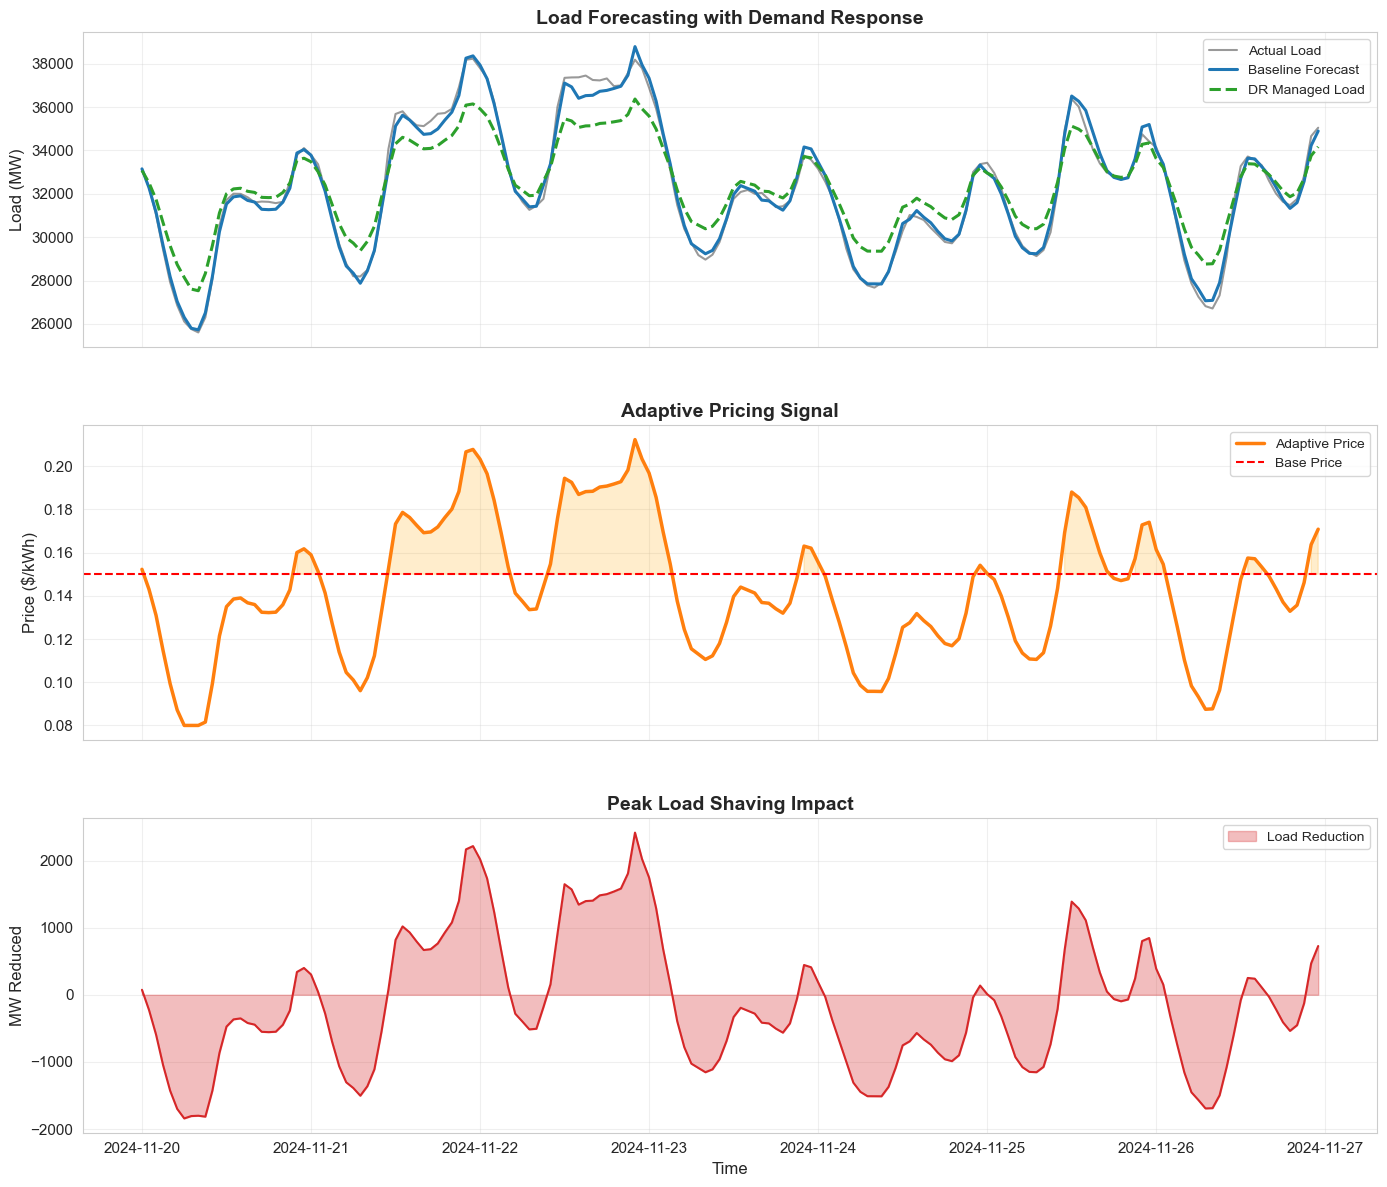

In [80]:
plot_results(results_df, days=7)

In [81]:
# Tariff Design & Demand Response Simulation
results = pd.DataFrame({'Actual': y_test, 'Forecast': xgb_preds}, index=test.index)
results.index = pd.to_datetime(results.index) # Ensure DatetimeIndex

# Time-of-Use (ToU) Windows
results['Tariff'] = 'Off-Peak'
results.loc[(results.index.hour >= 18) & (results.index.hour < 23), 'Tariff'] = 'Peak'
results['Price'] = np.where(results['Tariff'] == 'Peak', TOU_PEAK_RATE, TOU_OFF_RATE)

# Critical Peak Pricing (CPP) Trigger (95th Percentile Rule)
daily_peaks = results['Forecast'].resample('D').max()
cpp_threshold = daily_peaks.quantile(0.95)
cpp_days = daily_peaks[daily_peaks > cpp_threshold].index.date

# Apply CPP Rates
results_dates = pd.Series(results.index.date, index=results.index)
results.loc[(results['Tariff'] == 'Peak') & (results_dates.isin(cpp_days)), 'Price'] = CPP_PREMIUM_RATE

# Demand Response (DR) Simulation
# Baseline Revenue (Flat rate approximation at IDR 1,500)
results['Revenue_Flat'] = results['Actual'] * 1000 * 1500 # MWh to kWh * IDR

# Managed Load Calculation
results['Managed_Load'] = results['Forecast']

# ToU Shift: -20% from Peak to Off-Peak
peak_mask = results['Tariff'] == 'Peak'
peak_shaved = results.loc[peak_mask, 'Forecast'] * TOU_ELASTICITY_SHIFT
results.loc[peak_mask, 'Managed_Load'] -= peak_shaved

# CPP Reduction: -30% during CPP events
cpp_mask = results['Price'] == CPP_PREMIUM_RATE
results.loc[cpp_mask, 'Managed_Load'] = results.loc[cpp_mask, 'Forecast'] * (1 - CPP_ELASTICITY_REDUCTION)

# Managed Revenue
results['Revenue_Adaptive'] = results['Managed_Load'] * 1000 * results['Price']


In [82]:
# --- Output Analysis ---
mape = mean_absolute_percentage_error(results['Actual'], results['Forecast']) * 100
peak_reduction = (1 - results['Managed_Load'].max() / results['Actual'].max()) * 100
rev_increase = (results['Revenue_Adaptive'].sum() / results['Revenue_Flat'].sum() - 1) * 100

print(f"Model MAPE: {mape:.2f}%")
print(f"Simulated Peak Reduction: {peak_reduction:.2f}%")
print(f"Simulated Revenue Change: {rev_increase:.2f}%")

Model MAPE: 0.84%
Simulated Peak Reduction: 5.92%
Simulated Revenue Change: 10.56%


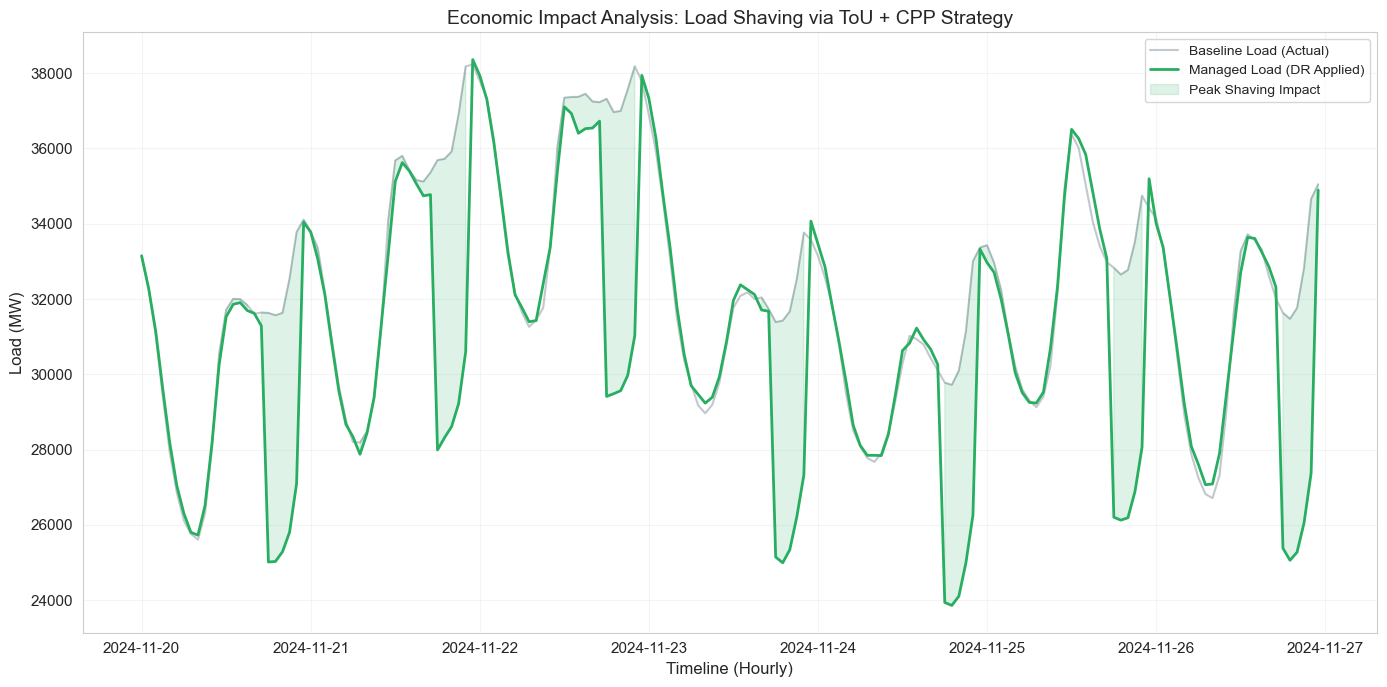

In [83]:
generate_final_report(results)

---

##### **Commercial**

In [64]:
cluster_df = load_and_aggregate_cluster(commercial_file, "Commercial")
X_train, y_train, X_test, y_test, test = train_test_split(cluster_df)


[Commercial] Loading and aggregating data...


In [65]:
import xgboost as xgb
xgb_reg = xgb.XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5,min_child_weight=5,colsample_bytree=1.0, 
                            tree_method='hist')
xgb_reg.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = xgb_reg.predict(X_test)
diction = { 'Model': 'XGBoost', 
                            'RMSE': np.sqrt(mean_squared_error(y_test, xgb_preds)), 
                            'MAE': mean_absolute_error(y_test, xgb_preds)}
diction

{'Model': 'XGBoost', 'RMSE': 762.450762470022, 'MAE': 511.97641986189035}

**Defining the base price and elasticity for simulation**

In [66]:
p_base = 0.35 
load_avg, load_std = y_train.mean(), y_train.std()
elasticity = 0.15

In [67]:
adaptive_prices = np.clip(p_base * (1 + 0.4 * (xgb_preds - load_avg) / load_std), 0.08, 0.45)
price_pct_change = (adaptive_prices - p_base) / p_base
dr_load = xgb_preds * (1 - elasticity * price_pct_change)

In [68]:
results_df = pd.DataFrame({
    'Actual_MW': y_test.values,
    'Predicted_Baseline_MW': xgb_preds,
    'Adaptive_Price_USD_kWh': adaptive_prices,
    'DR_Forecasted_Load_MW': dr_load
}, index=test.index)
results_df

,Actual_MW,Predicted_Baseline_MW,Adaptive_Price_USD_kWh,DR_Forecasted_Load_MW
datetime_beginning_utc,,,,
2024-11-20 00:00:00,56204.694,56606.109375,0.358656,56396.117188
2024-11-20 01:00:00,54601.965,54774.894531,0.334262,55144.355469
2024-11-20 02:00:00,52432.363,52602.105469,0.305317,53609.437500
2024-11-20 03:00:00,49808.684,49941.007812,0.269867,51656.121094
2024-11-20 04:00:00,47081.040,47389.636719,0.235879,49707.417969
...,...,...,...,...
2026-02-01 00:00:00,82831.285,82342.664062,0.450000,78813.687500
2026-02-01 01:00:00,82261.388,82086.945312,0.450000,78568.929688
2026-02-01 02:00:00,81150.576,80015.390625,0.450000,76586.156250


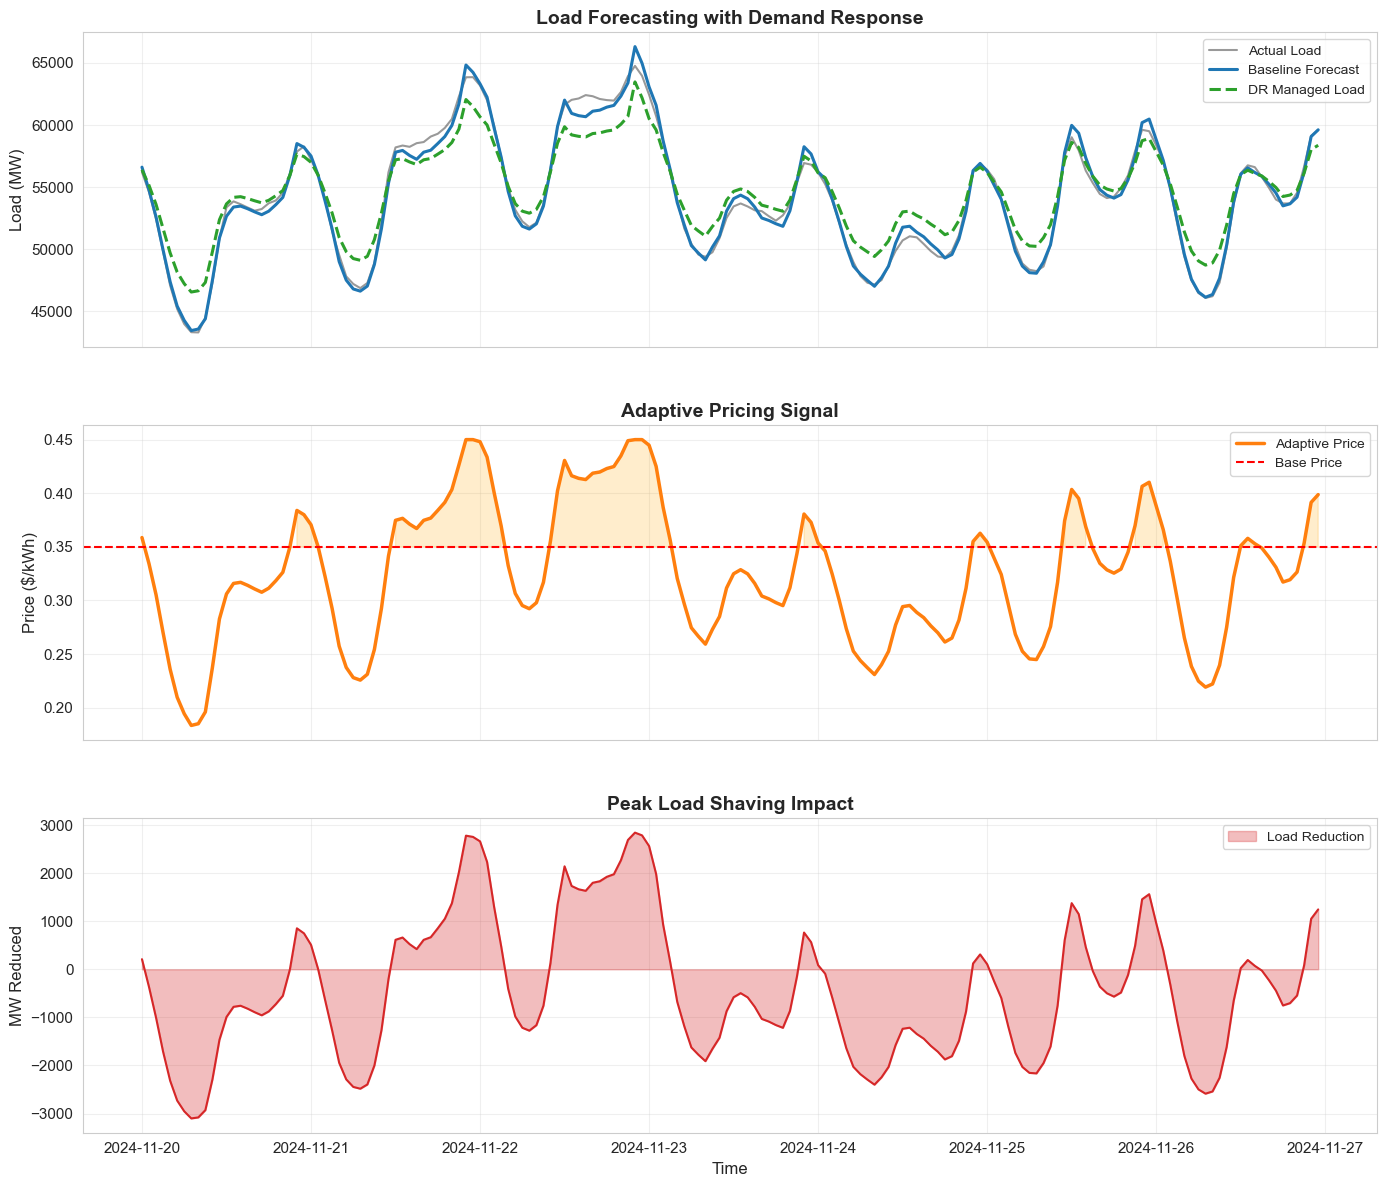

In [69]:
plot_results(results_df, days=7)

**According to Paper**

In [70]:
# Tariff Design & Demand Response Simulation
results = pd.DataFrame({'Actual': y_test, 'Forecast': xgb_preds}, index=test.index)
results.index = pd.to_datetime(results.index) # Ensure DatetimeIndex

# Time-of-Use (ToU) Windows
results['Tariff'] = 'Off-Peak'
results.loc[(results.index.hour >= 18) & (results.index.hour < 23), 'Tariff'] = 'Peak'
results['Price'] = np.where(results['Tariff'] == 'Peak', TOU_PEAK_RATE, TOU_OFF_RATE)

# Critical Peak Pricing (CPP) Trigger (95th Percentile Rule)
daily_peaks = results['Forecast'].resample('D').max()
cpp_threshold = daily_peaks.quantile(0.95)
cpp_days = daily_peaks[daily_peaks > cpp_threshold].index.date

# Apply CPP Rates
results_dates = pd.Series(results.index.date, index=results.index)
results.loc[(results['Tariff'] == 'Peak') & (results_dates.isin(cpp_days)), 'Price'] = CPP_PREMIUM_RATE

# Demand Response (DR) Simulation
# Baseline Revenue (Flat rate approximation at IDR 1,500)
results['Revenue_Flat'] = results['Actual'] * 1000 * 1500 # MWh to kWh * IDR

# Managed Load Calculation
results['Managed_Load'] = results['Forecast']

# ToU Shift: -20% from Peak to Off-Peak
peak_mask = results['Tariff'] == 'Peak'
peak_shaved = results.loc[peak_mask, 'Forecast'] * TOU_ELASTICITY_SHIFT
results.loc[peak_mask, 'Managed_Load'] -= peak_shaved

# CPP Reduction: -30% during CPP events
cpp_mask = results['Price'] == CPP_PREMIUM_RATE
results.loc[cpp_mask, 'Managed_Load'] = results.loc[cpp_mask, 'Forecast'] * (1 - CPP_ELASTICITY_REDUCTION)

# Managed Revenue
results['Revenue_Adaptive'] = results['Managed_Load'] * 1000 * results['Price']


In [71]:
# --- Output Analysis ---
mape = mean_absolute_percentage_error(results['Actual'], results['Forecast']) * 100
peak_reduction = (1 - results['Managed_Load'].max() / results['Actual'].max()) * 100
rev_increase = (results['Revenue_Adaptive'].sum() / results['Revenue_Flat'].sum() - 1) * 100

print(f"Model MAPE: {mape:.2f}%")
print(f"Simulated Peak Reduction: {peak_reduction:.2f}%")
print(f"Simulated Revenue Change: {rev_increase:.2f}%")

Model MAPE: 0.83%
Simulated Peak Reduction: 7.35%
Simulated Revenue Change: 10.99%


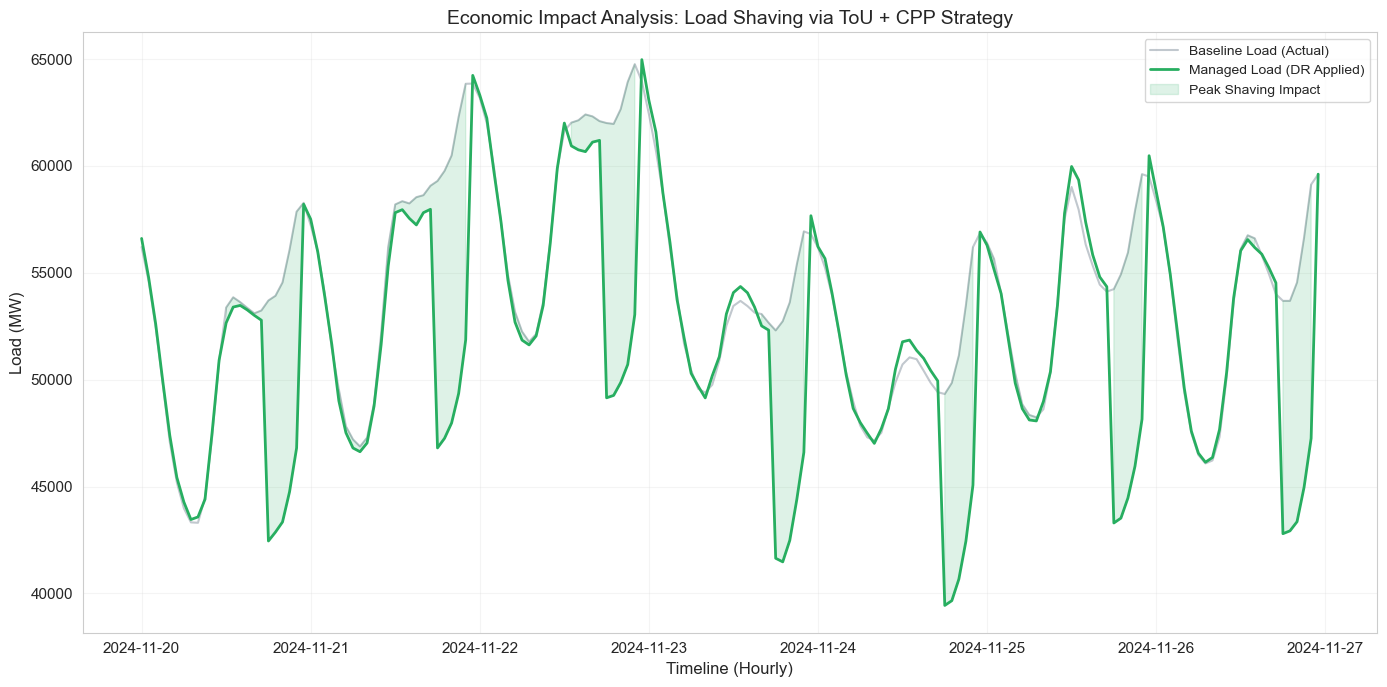

In [72]:
generate_final_report(results)

---

##### **Industrial**


In [24]:
cluster_df = load_and_aggregate_cluster(industrial_file, "Industrial")
X_train, y_train, X_test, y_test, test = train_test_split(cluster_df)


[Industrial] Loading and aggregating data...


In [25]:
import xgboost as xgb
xgb_reg = xgb.XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=5,min_child_weight=5,colsample_bytree=1.0, 
                            tree_method='hist')
xgb_reg.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds = xgb_reg.predict(X_test)
diction = { 'Model': 'XGBoost', 
                            'RMSE': np.sqrt(mean_squared_error(y_test, xgb_preds)), 
                            'MAE': mean_absolute_error(y_test, xgb_preds)}
diction

{'Model': 'XGBoost', 'RMSE': 1173.5406153741149, 'MAE': 796.536773025221}

**Defining the base price and elasticity of demand for simulation**

In [26]:
p_base = 0.20 
load_avg, load_std = y_train.mean(), y_train.std()
elasticity = 0.15

In [27]:
adaptive_prices = np.clip(p_base * (1 + 0.4 * (xgb_preds - load_avg) / load_std), 0.08, 0.45)
price_pct_change = (adaptive_prices - p_base) / p_base
dr_load = xgb_preds * (1 - elasticity * price_pct_change)

In [28]:
results_df = pd.DataFrame({
    'Actual_MW': y_test.values,
    'Predicted_Baseline_MW': xgb_preds,
    'Adaptive_Price_USD_kWh': adaptive_prices,
    'DR_Forecasted_Load_MW': dr_load
}, index=test.index)
results_df

,Actual_MW,Predicted_Baseline_MW,Adaptive_Price_USD_kWh,DR_Forecasted_Load_MW
datetime_beginning_utc,,,,
2024-11-20 00:00:00,89313.852,89681.250000,0.203910,89418.242188
2024-11-20 01:00:00,86910.997,87789.093750,0.194492,88151.726562
2024-11-20 02:00:00,83466.223,83659.226562,0.173937,85294.554688
2024-11-20 03:00:00,79228.133,79485.859375,0.153165,82277.914062
2024-11-20 04:00:00,75004.645,75352.171875,0.132590,79161.789062
...,...,...,...,...
2026-02-01 00:00:00,131851.028,130338.281250,0.406272,110174.398438
2026-02-01 01:00:00,130893.780,129997.171875,0.404574,110051.601562
2026-02-01 02:00:00,129036.020,128433.164062,0.396790,109477.390625


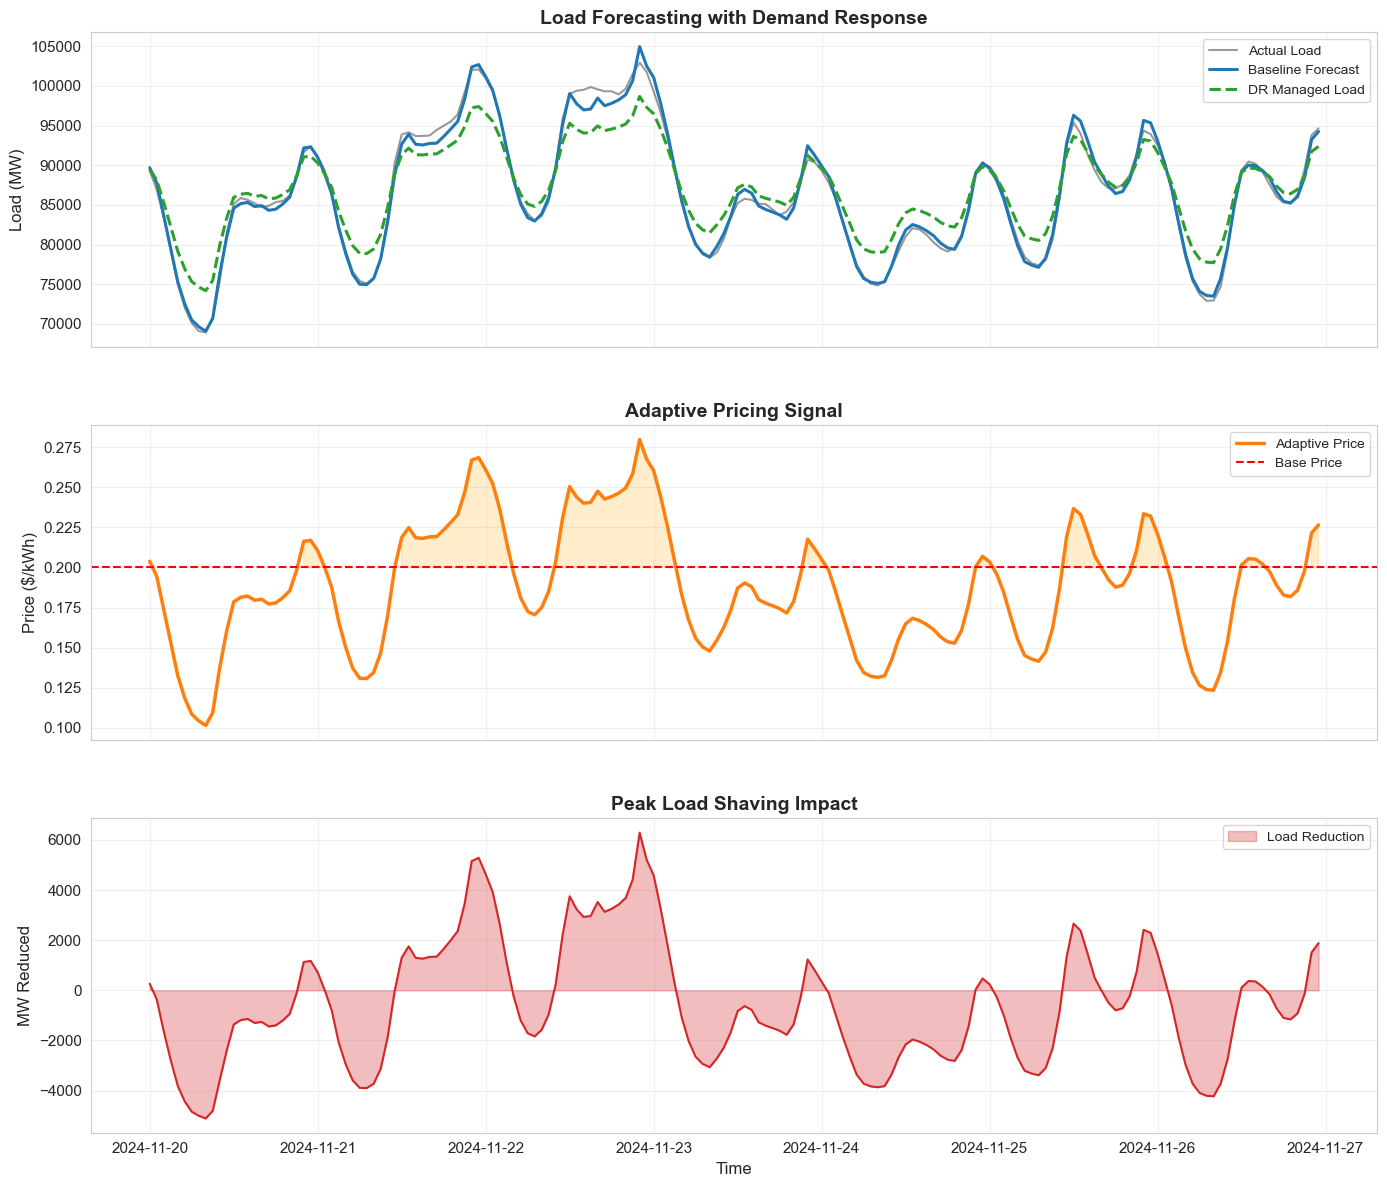

In [29]:
plot_results(results_df, days=7)

**According to Paper**

In [58]:
# Tariff Design & Demand Response Simulation
results = pd.DataFrame({'Actual': y_test, 'Forecast': xgb_preds}, index=test.index)
results.index = pd.to_datetime(results.index) # Ensure DatetimeIndex

# Time-of-Use (ToU) Windows
results['Tariff'] = 'Off-Peak'
results.loc[(results.index.hour >= 18) & (results.index.hour < 23), 'Tariff'] = 'Peak'
results['Price'] = np.where(results['Tariff'] == 'Peak', TOU_PEAK_RATE, TOU_OFF_RATE)

# Critical Peak Pricing (CPP) Trigger (95th Percentile Rule)
daily_peaks = results['Forecast'].resample('D').max()
cpp_threshold = daily_peaks.quantile(0.95)
cpp_days = daily_peaks[daily_peaks > cpp_threshold].index.date

# Apply CPP Rates
results_dates = pd.Series(results.index.date, index=results.index)
results.loc[(results['Tariff'] == 'Peak') & (results_dates.isin(cpp_days)), 'Price'] = CPP_PREMIUM_RATE

# Demand Response (DR) Simulation
# Baseline Revenue (Flat rate approximation at IDR 1,500)
results['Revenue_Flat'] = results['Actual'] * 1000 * 1500 # MWh to kWh * IDR

# Managed Load Calculation
results['Managed_Load'] = results['Forecast']

# ToU Shift: -20% from Peak to Off-Peak
peak_mask = results['Tariff'] == 'Peak'
peak_shaved = results.loc[peak_mask, 'Forecast'] * TOU_ELASTICITY_SHIFT
results.loc[peak_mask, 'Managed_Load'] -= peak_shaved

# CPP Reduction: -30% during CPP events
cpp_mask = results['Price'] == CPP_PREMIUM_RATE
results.loc[cpp_mask, 'Managed_Load'] = results.loc[cpp_mask, 'Forecast'] * (1 - CPP_ELASTICITY_REDUCTION)

# Managed Revenue
results['Revenue_Adaptive'] = results['Managed_Load'] * 1000 * results['Price']


In [59]:
# --- Output Analysis ---
mape = mean_absolute_percentage_error(results['Actual'], results['Forecast']) * 100
peak_reduction = (1 - results['Managed_Load'].max() / results['Actual'].max()) * 100
rev_increase = (results['Revenue_Adaptive'].sum() / results['Revenue_Flat'].sum() - 1) * 100

print(f"Model MAPE: {mape:.2f}%")
print(f"Simulated Peak Reduction: {peak_reduction:.2f}%")
print(f"Simulated Revenue Change: {rev_increase:.2f}%")

Model MAPE: 0.81%
Simulated Peak Reduction: 6.74%
Simulated Revenue Change: 10.82%


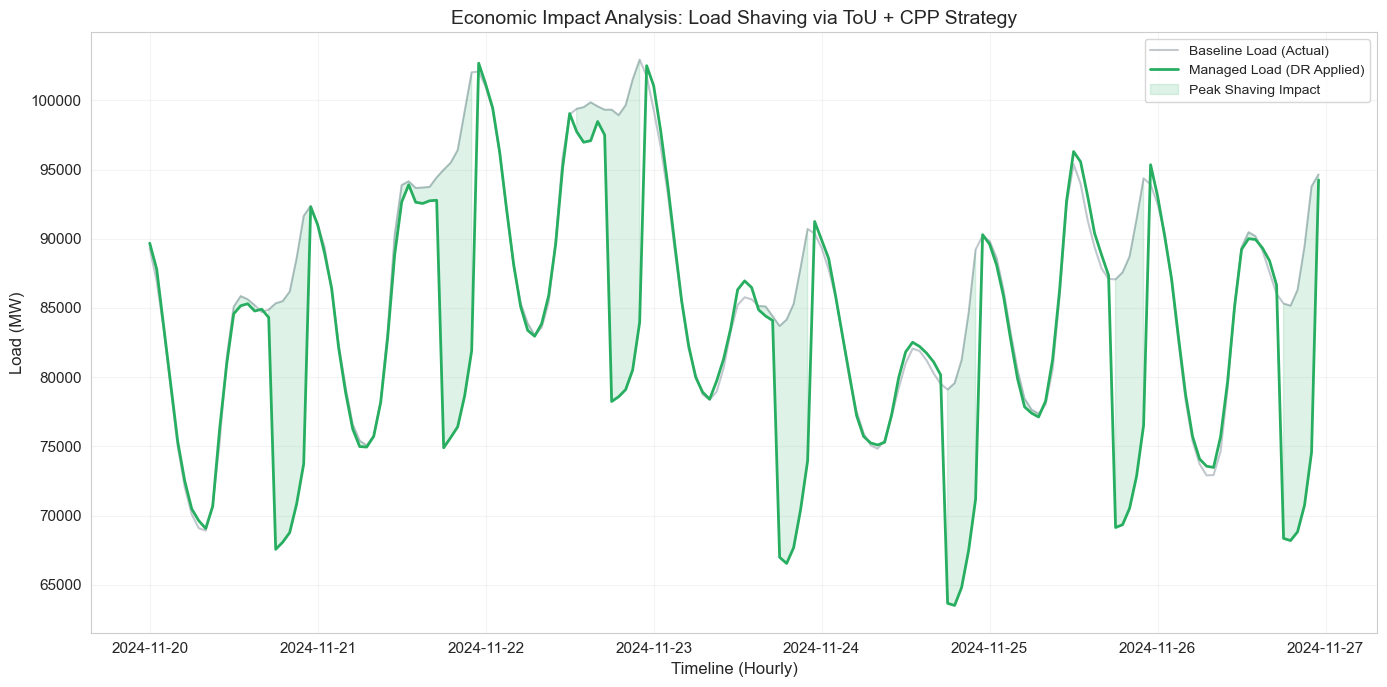

In [60]:
generate_final_report(results)

---

**Results** 

* We can see that the model performed pretty well . 
* We have assumed an elasticity of 0.15 here. 
* The demand response curve is as shown in the figures.
* We have assumed a base price of 0.15 for residential, 0.35 for commercial and 0.20 for industrial.
* We might need real world application tests to fully prove our claim.

---